Fundamentals of Deep Learning Models

# Lab 07-2: YOLO for Object Detection
## Exercise: Implement YOLO-v1 with ResNet-50 backbone

This exercise implements a complete **YOLO-v1 object detection pipeline** (Section 7.5) on the PASCAL VOC 2007 dataset. The model uses a **ResNet-50 backbone** (Section 6.5) pretrained on ImageNet as a feature extractor via transfer learning (Section 6.7), followed by YOLO-v1 head layers that produce the $(S, S, 5B + N_{\text{class}})$ output tensor (Eq. 7.7). The pipeline includes data preprocessing with augmentation, the YOLO-v1 loss function (Eqs. 7.8–7.13), non-maximum suppression for post-processing (Section 7.3), and IoU-based evaluation (Eq. 7.2).

**Implementation notes:** This implementation uses sigmoid for confidence, softmax for class probabilities, and log-space parameterization for bounding box height/width, which differ from the original YOLO-v1 formulation (Section 7.5).

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 1.26.4
TensorFlow version: 2.16.1
Keras version: 3.4.1
TensorFlow Datasets version: 4.9.9
Matplotlib version: 3.9.1
Num GPUs Available:  1


This dataset is an untouched version of PASCAL 2007 and 2012 dataset.

VOC2007 DATASET obtained from:
http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar
http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtest_06-Nov-2007.tar

VOC2012 DATASET obtained from:
http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

In [2]:
# Load PASCAL VOC 2007 dataset (CC-BY-NC license, 20 object classes)
dataset = 'voc2007'

if dataset == 'voc2007':
    # Load the original voc2007 dataset
    # Each image contains a small object such as bird, truck, etc...
    (ds_train, ds_test, ds_val), ds_info = tfds.load('voc/2007', split=['test', 'train', 'validation'],
                                                 batch_size=None, shuffle_files=True, 
                                                 with_info=True)
elif dataset == 'voc2012':
    # Load the original voc2007 dataset
    # The test of voc2012 dataset has no annotation.
    (ds_train, ds_test, ds_val), ds_info = tfds.load('voc/2012', split=['train', 'test', 'validation'],
                                                 batch_size=None, shuffle_files=True, 
                                                 with_info=True)
else:
    print('Dataset Error')

print(ds_info.features)
print(ds_info.splits)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/swx/tensorflow_datasets/voc/2007/incomplete.FPM1K1_5.0.0/voc-train.tfrecord*...:   0%|        …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/swx/tensorflow_datasets/voc/2007/incomplete.FPM1K1_5.0.0/voc-validation.tfrecord*...:   0%|   …

Dataset voc downloaded and prepared to /home/swx/tensorflow_datasets/voc/2007/5.0.0. Subsequent calls will reuse this data.
FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'image/filename': Text(shape=(), dtype=string),
    'labels': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=20)),
    'labels_no_difficult': Sequence(ClassLabel(shape=(), dtype=int64, num_classes=20)),
    'objects': Sequence({
        'bbox': BBoxFeature(shape=(4,), dtype=float32),
        'is_difficult': bool,
        'is_truncated': bool,
        'label': ClassLabel(shape=(), dtype=int64, num_classes=20),
        'pose': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
})
{Split('test'): <SplitInfo num_examples=4952, num_shards=4>, Split('train'): <SplitInfo num_examples=2501, num_shards=2>, Split('validation'): <SplitInfo num_examples=2510, num_shards=2>}


In [3]:
classes = ds_info.features['labels'].names
n_classes = ds_info.features['labels'].num_classes
n_channels = ds_info.features['image'].shape[-1]

n_train = len(ds_train)
n_test = len(ds_test)
n_val = len(ds_val)

print('The original dataset has these samples.')
for splt in ds_info.splits:
    print(splt, 'has', ds_info.splits[splt].num_examples, 'examples.')
print('The train and test are exchanged for this experiments.')

The original dataset has these samples.
test has 4952 examples.
train has 2501 examples.
validation has 2510 examples.
The train and test are exchanged for this experiments.


### Data preprocessing: convert VOC annotations to YOLO grid format

The function `tfds_augmtd_4_YOLO` converts each image and its bounding box annotations into the YOLO-v1 tensor format. For each object, the bounding box center is mapped to a grid cell, and the offset within the cell is computed (Eq. 7.5). The output label tensor has shape $(S, S, C_{\text{cell}}) = (7, 7, 30)$, where each cell stores confidence, center offset, height, width for $B=2$ boxes, plus 20 class probabilities (Eq. 7.7). Data augmentation includes random cropping (90–100%) and horizontal flipping.

In [4]:
# PASCAL VOC dataset fields:
#   'image': (H, W, 3) image tensor
#   'objects'/'bbox': [y1/H, x1/W, y2/H, x2/W] normalized coordinates
#   'objects'/'label': integer class labels

def tfds_augmtd_4_YOLO(element, preprocess=True):
    """Preprocess a VOC sample into YOLO-v1 format.
    
    Converts bounding boxes to the YOLO grid-cell representation:
    each cell predicts (confidence, y_offset, x_offset, h, w) for B=2 boxes
    plus N_class one-hot probabilities, totaling 30 values per cell (Eq. 7.7).
    Center offsets are relative to the grid cell (Eq. 7.5).
    """

    if tf.random.uniform([])>0.5:
        flip_image = True
    else:
        flip_image = False

    image_shape = (448,448)           # YOLO-v1 input size (Table 7.1)
    grid_h, grid_w = 7, 7            # S = 7 grid resolution

    # Random crop augmentation: crop 90–100% of the image
    scale_var = 0.1
    scale = tf.random.uniform([]) * scale_var + (1-scale_var)    
    img_y1 = tf.random.uniform([]) * (1 - scale)
    img_x1 = tf.random.uniform([]) * (1 - scale)
    img_y2 = img_y1 + scale
    img_x2 = img_x1 + scale

    crop_b = tf.expand_dims([img_y1, img_x1, img_y2, img_x2], axis=0)
    crop_i = np.zeros((1))

    in_image = tf.expand_dims(element['image'], axis=0)

    # Crop and resize to 448x448
    image = tf.image.crop_and_resize(in_image,
                                     boxes=crop_b, box_indices=crop_i, 
                                     crop_size=image_shape,
                                     method='bilinear')

    if preprocess:
        image = keras.applications.resnet50.preprocess_input(image)
    else:
        pass

    image = tf.squeeze(image, axis=0)

    # Output tensor: C_cell = 5*B + N_class = 5*2 + 20 = 30 (Eq. 7.7)
    n_para = 4+1+4+1+n_classes

    label = tf.zeros((grid_h,grid_w,n_para))
    tiles = tf.zeros((grid_h,grid_w))

    for i in range(len(element['objects']['bbox'])):
        # Get original bounding box in normalized coordinates
        bbox_y1 = element['objects']['bbox'][i][0]
        bbox_x1 = element['objects']['bbox'][i][1]
        bbox_y2 = element['objects']['bbox'][i][2]
        bbox_x2 = element['objects']['bbox'][i][3]
        bbox_h, bbox_w = bbox_y2 - bbox_y1, bbox_x2 - bbox_x1

        # Clip bounding box to cropped image region
        cbox_y1 = tf.maximum(img_y1, bbox_y1)
        cbox_x1 = tf.maximum(img_x1, bbox_x1)
        cbox_y2 = tf.minimum(img_y2, bbox_y2)
        cbox_x2 = tf.minimum(img_x2, bbox_x2)
        cbox_h = cbox_y2 - cbox_y1 if (cbox_y2 > cbox_y1) else 0.0
        cbox_w = cbox_x2 - cbox_x1 if (cbox_x2 > cbox_x1) else 0.0

        # Keep object if >60% of its area remains after cropping
        if bbox_h*bbox_w*0.6 < cbox_h*cbox_w:
            cls_n = element['objects']['label'][i]
            # Rescale box coordinates relative to cropped image
            box_y, box_x = (cbox_y1 - img_y1)/scale, (cbox_x1 - img_x1)/scale
            box_h, box_w = cbox_h/scale, cbox_w/scale
            # Find center coordinates
            bxc_y, bxc_x = box_y + box_h / 2, box_x + box_w / 2
            if bxc_y>=1.0: bxc_y=1.0-1e-4
            if bxc_x>=1.0: bxc_x=1.0-1e-4

            # Determine grid cell index and offset within cell (Eq. 7.5)
            y_f, x_f = grid_h * bxc_y, grid_w * bxc_x
            y_n, x_n = tf.math.floor(y_f), tf.math.floor(x_f)
            y_i, x_i = tf.cast(y_n, dtype=tf.int32), tf.cast(x_n, dtype=tf.int32)
            bxo_y, bxo_x = y_f - y_n, x_f - x_n

            # If multiple objects in same cell, keep the larger one
            new_area = box_w * box_h
            if (new_area > tiles[y_i, x_i]):
                tdiff = tf.scatter_nd(indices=[[y_i,x_i]],
                                      updates=[new_area-tiles[y_i,x_i]], 
                                      shape=[grid_h,grid_w])
                tiles = tiles + tdiff

                lmask = tf.ones_like(label) - tf.scatter_nd(indices=[[[y_i,x_i]]], 
                                                            updates=tf.ones((1,1,n_para)), 
                                                            shape=[grid_h,grid_w,n_para])
                label = label * lmask

                one_h = tf.one_hot(cls_n, depth=n_classes)
                if flip_image:
                    bxo_x = 1 - bxo_x
                # Box 1: responsible (confidence=1), Box 2: null (confidence=0)
                tboxc = [1.0, bxo_y, bxo_x, box_h, box_w]
                nboxc = [0.0, bxo_y, bxo_x, box_h, box_w]
                bcord = tf.concat([tboxc, nboxc, one_h], axis=-1)
                label = label + tf.scatter_nd(indices=[[[y_i,x_i]]],
                                               updates=bcord[tf.newaxis,tf.newaxis,:], 
                                               shape=[grid_h,grid_w,n_para])

    if flip_image:
        image = tf.image.flip_left_right(image)
        label = tf.reverse(label, [1])

    return image, label

In [5]:
def image_augmentation(elements):
    """Apply color augmentation (brightness, contrast, saturation) to input image."""

    image = elements['image']
    image = tf.image.random_brightness(image, max_delta=0.1, seed=None)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2, seed=None)
    image = tf.image.random_saturation(image, lower=0.9, upper=1.1, seed=None)

    image = tf.clip_by_value(image, clip_value_min=0, clip_value_max=255)

    augmented_e = elements
    augmented_e['image'] = image

    return augmented_e

In [6]:
N_BATCH = 64

# Training data: augment colors, convert to YOLO format, shuffle, batch
dataset = ds_train.map(image_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.map(tfds_augmtd_4_YOLO, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size = 256).batch(batch_size=N_BATCH)

# Validation data: convert to YOLO format (no color augmentation)
valiset = ds_val.map(tfds_augmtd_4_YOLO, num_parallel_calls=tf.data.AUTOTUNE)
valiset = valiset.shuffle(buffer_size = 256).batch(batch_size=N_BATCH)

# Test data: convert to YOLO format
testset = ds_test.map(tfds_augmtd_4_YOLO, num_parallel_calls=tf.data.AUTOTUNE)
testset = testset.shuffle(buffer_size = 256).batch(batch_size=N_BATCH)

### Visualize a sample with ground-truth bounding boxes

chair
pottedplant
tf.Tensor(0, shape=(), dtype=uint8) tf.Tensor(255, shape=(), dtype=uint8)


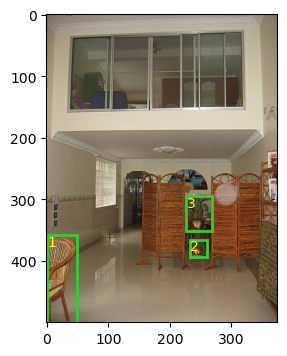

1 : chair
2 : pottedplant
3 : pottedplant


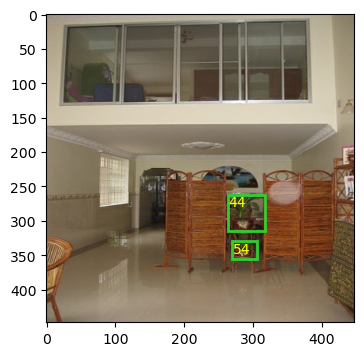

44 : pottedplant
54 : pottedplant


In [7]:
# Get one sample of dataset
for element in ds_train.take(1):
    sample = element

for i in sample['labels']: print(classes[i])

img_h, img_w, _ = sample['image'].shape

plt.figure(figsize=(4,4))
plt.imshow(sample['image']/255)
axs = plt.gca()   # get current axes

for i in range(len(sample['objects']['bbox'])):
    s_y, s_x, e_y, e_x = sample['objects']['bbox'][i].numpy()
    obj_x, obj_y, obj_w, obj_h = s_x*img_w, s_y*img_h, (e_x-s_x)*img_w, (e_y-s_y)*img_h
    bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h,
                 linewidth=2, edgecolor='limegreen', fill = False)
    axs.add_patch(bbox)
    plt.text(obj_x+1, obj_y+17, str(i+1), color='yellow')

print(tf.reduce_min(sample['image']), tf.reduce_max(sample['image']))
plt.show()

for i in range(len(sample['objects']['label'])):
    print(i+1, ':', classes[sample['objects']['label'][i].numpy()])

images, labels = tfds_augmtd_4_YOLO(sample, preprocess=False)

plt.figure(figsize=(4,4))
plt.imshow(images/256)
axs = plt.gca()   # get current axes
img_h, img_w, _ = images.shape
for i in range(7):
    for j in range(7):
        if labels[i,j,0]==1:
            c_y, c_x, c_h, c_w = labels[i,j,1:5]
            c_y, c_x = (c_y + i)/7, (c_x + j)/7
            obj_y, obj_x, obj_h, obj_w = (c_y-c_h/2)*img_h, (c_x-c_w/2)*img_w, c_h*img_h, c_w*img_w
            bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h, linewidth=2, edgecolor='limegreen', fill = False)
            axs.add_patch(bbox)
            plt.text(obj_x+1, obj_y+17, str(i)+str(j), color='yellow')

plt.show()

for i in range(7):
    for j in range(7):
        if labels[i,j,0]==1:
            print(str(i)+str(j),':',classes[np.argmax(labels[i,j,10:])])


### Network definition with Keras Functional API

The YOLO-v1 model (Section 7.5, Table 7.1) is constructed using a **ResNet-50 backbone** (Section 6.5) pretrained on ImageNet for transfer learning (Section 6.7), followed by detection-specific head layers. The backbone is initially frozen during training.

In [8]:
# Weight initialization: He normal (Section 4.4)
layer_init = keras.initializers.HeNormal(seed=None)
# L2 regularization (Section 4.5)
l2_regular = keras.regularizers.L2(l2=1e-2)
# Leaky ReLU with slope 0.1 as used in YOLO-v1 (Section 7.5)
leaky_relu = keras.layers.LeakyReLU(negative_slope=0.1)

In [9]:
# ResNet50 has 50 layers including fully connected top layers
n_layers = len(keras.applications.resnet50.ResNet50(include_top=False).layers)

print('The number of layers in ResNet50 backbone is', n_layers)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
The number of layers in ResNet50 backbone is 175


In [10]:
# ResNet-50 backbone pretrained on ImageNet (Section 6.5, 6.7)
# include_top=False removes the classification head, keeping only feature extraction layers
yolo_inputs = keras.Input(shape=(448, 448, 3))

YOLO_base = keras.applications.resnet50.ResNet50(include_top=False, 
                                                    weights='imagenet', 
                                                    input_tensor=yolo_inputs,
                                                    input_shape=(448, 448, 3),
                                                    pooling=None)

# Freeze backbone weights for transfer learning (Section 6.7)
YOLO_base.trainable = False

In [ ]:
# Build YOLO-v1 detection head on top of ResNet-50 backbone

X = YOLO_base(yolo_inputs, training=False)

### START CODE HERE ###

# Conv layers 21-22: 1024-channel feature processing with stride-2 downsampling
# Corresponds to layers 21-22 in Table 7.1 (adapted for ResNet backbone)
X = keras.layers.Conv2D(...)(X)
X = keras.layers.BatchNormalization()(X)
X = keras.layers.LeakyReLU(...)(X)
...

# Conv layers 23-24: additional 1024-channel feature refinement
X = keras.layers.Conv2D(...)(X)
...

# FC layer 25: flatten → 4096 with dropout (Table 7.1, layer 25)
X = keras.layers.Flatten()(X)
X = keras.layers....

# FC layer 26: output 7x7x30 = 1470 (Table 7.1, layer 26)
X = keras.layers.Dense(...)(X)

# Reshape to (S, S, C_cell) = (7, 7, 30) grid output (Eq. 7.7)
yolo_outputs = keras.layers....

### END CODE HERE ###

# Combine backbone and head into a single model
YOLO = keras.Model(inputs=yolo_inputs, outputs=yolo_outputs, name='myYOLO')

### Training model and showing history

In [12]:
YOLO.summary()

with open('YOLO2summary.txt','w+') as f:
    YOLO.summary(print_fn=lambda x: f.write(x + '\n'))
    f.close()

# keras.utils.plot_model(ResNet, "my_first_model_with_shape_info.png", show_shapes=True)

Model: "myYOLO"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 14, 14, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 1024)   │    18,875,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   205,524,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1470)           │     6,022,590 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Reshape)                │ (None, 7, 7, 30)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,341,694 (1.05 GB)

 Trainable params: 258,745,790 (987.04 MB)

 Non-trainable params: 23,595,904 (90.01 MB)

### Define loss function (From Lab 07-1)
The original YOLO-v1 evaluates object confidence and class probabilities with MSE on raw values (Section 7.5). This implementation uses **sigmoid** for confidence and **softmax** for class probabilities for improved numerical stability. Bounding box height and width use **log-space** parameterization. The confidence target for the responsible predictor uses the IoU value as defined in Eq. (7.11).

In [ ]:
def yolo_loss_fn(y_true, y_pred):
    """YOLO-v1 loss function (Eqs. 7.8-7.13)."""
    
    l_coord = 5.0  # lambda_coord (Section 7.5: lambda_coord = 5)
    l_noobj = 0.5  # lambda_noobj (Section 7.5: lambda_noobj = 0.5)
    n_grid = 7     # S = 7 grid resolution
    n_batch = tf.shape(y_true)[0]

    # Build grid index arrays for offset-to-absolute conversion (Eq. 7.5)
    idx_tmp = tf.stack(tf.meshgrid(tf.range(7.0), tf.range(7.0), indexing='ij'), axis=-1) # (S,S,2)
    idx_arr = tf.repeat(idx_tmp[None,:,:,None,:], repeats=2, axis=-2)   # (1,S,S,2,2)

    # ---- Parse ground truth tensor ----
    # Duplicate for B=2 box proposals
    y_true_ep = tf.expand_dims(y_true, axis=-2)          # (b,S,S,1,30)
    y_true_rp = tf.repeat(y_true_ep, repeats=2, axis=-2) # (b,S,S,2,30)

    ### START CODE HERE ###

    # Extract true center offsets and convert to absolute coords (Eq. 7.5)
    true_bxyx = None                                     # (b,S,S,2,2) offset (y,x)
    true_c_yx = None                                     # (b,S,S,2,2) absolute (y,x)
    # Extract true height and width
    true_c_hw = None                                     # (b,S,S,2,2) = (h,w)

    # Extract true one-hot class probabilities
    true_clss = None                                     # (b,S,S,20)

    ### END CODE HERE ###
    
    # ---- Parse prediction tensor ----
    y_pred_rs = tf.reshape(y_pred[..., :10], [n_batch,n_grid,n_grid,2,5]) # (b,S,S,2,5)

    ### START CODE HERE ###

    # Apply sigmoid to confidence logits (Section 7.5 note)
    pred_cnf0 = None                                     # (b,S,S,2) raw logits
    pred_conf = None                                     # (b,S,S,2) probabilities

    # Extract predicted center offsets → absolute coords (Eq. 7.5)
    pred_bxyx = None                                     # (b,S,S,2,2) offset (y,x)
    pred_c_yx = None                                     # (b,S,S,2,2) absolute (y,x)

    # Apply exp() to h,w logits (log-space parameterization)
    pred_c_hw = None                                     # (b,S,S,2,2) = (h,w)

    # Apply softmax to class logits
    pred_clss = None                                     # (b,S,S,20)

    ### END CODE HERE ###

    # ---- Compute IoU for responsible predictor selection (Eq. 7.1, 7.2) ----

    ### START CODE HERE ###

    # Convert center+size to corner coordinates
    true_b_yx = None                                     # (b,S,S,2,2) bottom-left
    true_t_yx = None                                     # (b,S,S,2,2) top-right
    pred_b_yx = None                                     # (b,S,S,2,2) bottom-left
    pred_t_yx = None                                     # (b,S,S,2,2) top-right

    # Compute intersection
    ovrl_b_yx = None                                     # (b,S,S,2,2)
    ovrl_t_yx = None                                     # (b,S,S,2,2)
    ovrl_bxhw = None                                     # (b,S,S,2,2)

    # Compute areas for IoU (Eq. 7.2)
    true_area = None                                     # (b,S,S,2)
    pred_area = None                                     # (b,S,S,2)
    ovrl_area = None                                     # (b,S,S,2)

    # IoU (Eq. 7.2)
    iou_value = None                                     # (b,S,S,2)

    ### END CODE HERE ###

    # ---- Generate indicator masks: 1^obj_ij and 1^noobj_ij ----

    ### START CODE HERE ###

    # Responsible predictor = higher IoU with ground truth (Section 7.5)
    iou_biggr = None                                     # (b,S,S,1)
    iou_smalr = None                                     # (b,S,S,1)
    iou_bmssk = None                                     # (b,S,S,2)

    # 1^obj_ij: object present AND responsible box (Eq. 7.9)
    true_objt = None                                     # (b,S,S,1) object presence
    true_objc = None                                     # (b,S,S,2) = 1^obj_ij
    # 1^noobj_ij: complement (Eq. 7.12)
    true_nbjc = None                                     # (b,S,S,2) = 1^noobj_ij

    # Confidence target: IoU for responsible box, 0 elsewhere (Eq. 7.11)
    true_conf = None                                     # (b,S,S,2)

    ### END CODE HERE ###

    # ---- Compute loss components ----

    ### START CODE HERE ###

    # Location loss L_xy (Eq. 7.9)
    loss_cyx0 = None                                     # (b,S,S,2,2)
    loss_c_yx = None                                     # (b,S,S,2)

    # Size loss L_wh (Eq. 7.10): sqrt for scale sensitivity
    loss_chw0 = None                                     # (b,S,S,2,2)
    loss_c_hw = None                                     # (b,S,S,2)
    loss_coordinate = None                               # (b,)
    
    # Confidence loss L_obj (Eq. 7.12): target=IoU for obj, target=0 for noobj
    loss_ob_c = None                                     # (b,S,S,2)
    loss_nb_c = None                                     # (b,S,S,2)
    loss_confidence = None                               # (b,)

    # Class probability loss L_class (Eq. 7.13)
    loss_clss = None                                     # (b,S,S,20)
    loss_classification = None                           # (b,)

    ### END CODE HERE ###

    loss = tf.reduce_mean(loss_coordinate + loss_confidence + loss_classification)

    return loss

#### Post-processing: decode predictions and filter by confidence

The function `yolo_head_filter` decodes the raw network output into bounding box coordinates. For each grid cell, it selects the box with higher confidence (after sigmoid), converts center+size to corner coordinates, computes class-specific scores by multiplying class probabilities (softmax) with box confidence, and filters boxes below a score threshold. This implements the prediction-side counterpart of the NMS pipeline described in Section 7.3.

In [ ]:
def yolo_head_filter(feats, n_grid=7, threshold=0.6):
    """Convert final layer features to bounding box parameters.

    Parameters
    ----------
    feats : tensor = (b, 7, 7, 30) = (b,g,g,pyxhw+pyxhw+cls)
        Final convolutional layer features.
    num_classes : int = 20
        Number of target classes.

    Returns:
    scores -- tensor of shape (None,), containing the class probability score for selected boxes
    boxes -- tensor of shape (None, 4), containing (b_x, b_y, b_h, b_w) coordinates of selected boxes
    classes -- tensor of shape (None,), containing the index of the class detected by the selected boxes
    
    Note: "None" is here because you don't know the exact number of selected boxes, as it depends on the threshold. 
    For example, the actual output size of scores would be (10,) if there are 10 boxes.
    """

    n_batch = tf.shape(feats)[0]
    n_cells = n_grid * n_grid
    
    idx_tmp = tf.stack(tf.meshgrid(tf.range(7.0), tf.range(7.0), indexing='ij'), axis=-1) # (g,g,2)
    idx_arr = tf.repeat(idx_tmp[None,:,:,None,:], repeats=2, axis=-2)   # (1,g,g,2,2)

    # Step 1: Compute box confidence and select the box with higher confidence for each cell

    ### START CODE HERE ### 
    
    # yolo_head for y_pred: box_confidence, box_yx, box_hw, box_class_probs
    # for yolov1, 2 predictions per grid is used
    box_feats = None                                         # (b,g,g,2,5)
    feat_conf = None                                         # (b,g,g,2) = (c1,c2)
    mask_hcnf = None                                         # (b,g,g,1) = conf mask for proposal 0
    mask_lcnf = None                                         # (b,g,g,1) = conf mask for proposal 1
    mask_conf = None                                         # (b,g,g,2) = high conf mask
    
    # box confidence
    boxs_conf = None                                         # (b,g,g,1) = high conf value
    
    ### END CODE HERE ###

    # Step 2: Find the box coordinates for the selected box in each cell, and apply the confidence mask

    ### START CODE HERE ### 
    
    # make coordinate: y1,x1,y2,x2
    mask_crd0 = None                                        # (b,g,g,2,1) = high conf mask
    mask_yxyx = None                                        # (b,g,g,2,4) = high conf coord mask

    boxs_cyx0 = None                                        # (b,g,g,2,2) = (y,x)_ofs
    boxs_c_yx = None                                        # (b,g,g,2,2) = (y,x)
    boxs_c_hw = None                                        # (b,g,g,2,2) = (h,w)  

    boxs_b_yx = None                                        # (b,g,g,2,2) = b(x,y)
    boxs_t_yx = None                                        # (b,g,g,2,2) = t(x,y)
    boxs_yxyx = None                                        # (b,g,g,2,4)
    boxs_crd1 = None                                        # (b,g,g,2,4)

    #### high confidence coordinates ####
    boxs_coord = None                                       # (b,g,g,4)
    
    ### END CODE HERE ###

    # Step 3: Create a boolean filtering mask for boxes with class probability score above the threshold

    ### START CODE HERE ###
    
    box_scores = None                                       # (b,g,g,20)
    # box class
    box_classes = None                                      # (b,g,g)
    # box score
    box_class_scores = None                                 # (b,g,g,1)

    filtering_mask = None                                   # (b,g,g,1)
    
    ## END CODE HERE ###

    # step 4: Apply the filtering mask to scores, boxes, and classes, and reshape output tensors
    scores = tf.reshape(box_class_scores * filtering_mask, [n_batch,n_cells]) # (b,gg)
    boxes = tf.reshape(boxs_coord * filtering_mask, [n_batch,n_cells,-1])     # (b,gg,4)
    classes = tf.reshape(box_classes, [n_batch,n_cells])                      # (b,gg)
    
    return scores, boxes, classes

#### Non-maximum suppression (NMS)

The function `yolo_predict_fn` applies non-maximum suppression (Section 7.3) to the filtered predictions using `tf.image.combined_non_max_suppression`. This removes redundant overlapping detections by keeping only the highest-scoring box among boxes with IoU above a threshold, producing the final set of detected objects.

In [15]:
def yolo_predict_fn(y_pred, threshold=0.6):

    scr_thr = threshold
    iou_thr = 0.5
    n_batch = tf.shape(y_pred)[0]
    n_classes = 20
    n_grid = 7
    n_cells = 7 * 7
    
    scores, boxes, classes = yolo_head_filter(y_pred, threshold=scr_thr)  # 

    classes_one_hot = tf.one_hot(classes, n_classes)  # (b,gg,20)

    scores_in = scores[..., tf.newaxis] * classes_one_hot              # (b,gg,20)

    classes_one_hot4 = tf.repeat(classes_one_hot[..., tf.newaxis], repeats=4, axis=-1) # (b,gg,20,4)

    bboxes_in = boxes[:,:,tf.newaxis,:] * classes_one_hot4    # (b,gg,20,4)

    # Apply NMS: boxes=(b,gg,20,4), scores=(b,gg,20) → filtered detections

    nms_bxs, nms_scr, nms_cls, val_det = tf.image.combined_non_max_suppression(
        bboxes_in, scores_in, max_output_size_per_class=n_cells, max_total_size=n_cells,
        iou_threshold=iou_thr,  score_threshold=scr_thr, pad_per_class=False, clip_boxes=True) 
 
    # Returns: nms_bxs (b,N,4), nms_scr (b,N), nms_cls (b,N), val_det (b,)

    return nms_bxs, nms_scr, nms_cls, val_det

#### Custom IoU metric for training monitoring

The `yolo_metric_fn` class wraps Keras `OneHotMeanIoU` to compute mean IoU during training. It extracts predicted class probabilities (softmax) weighted by the maximum box confidence (sigmoid) and compares them with ground-truth one-hot labels.

In [16]:
class yolo_metric_fn(keras.metrics.Metric):
    def __init__(self, num_classes, name='yolo_metric_fn', **kwargs):
        super(yolo_metric_fn, self).__init__(name=name, **kwargs)
        self.mean_iou = keras.metrics.OneHotMeanIoU(num_classes=num_classes)

    def update_state(self, y_true, y_pred, sample_weight=None):
        true_classes = y_true[...,10:]
        esti_cls = tf.nn.softmax(y_pred[...,10:], axis=-1)
        pred_cnf = tf.maximum(tf.sigmoid(y_pred[...,0:1]),tf.sigmoid(y_pred[...,5:6])) 
        pred_classes = esti_cls * pred_cnf
        self.mean_iou.update_state(true_classes, pred_classes, sample_weight)

    def result(self):
        return self.mean_iou.result()

    def reset_states(self):
        # The state of the metric will be reset at the start of each epoch.
        self.mean_iou.reset_state()

In [17]:
# Compile with SGD optimizer and YOLO loss function
opt = keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)
YOLO.compile(
    optimizer=opt, 
    loss=yolo_loss_fn, 
    metrics=['acc', yolo_metric_fn(num_classes=n_classes)],
    jit_compile=False,
    )

### Training

In [ ]:
# Learning rate schedule with warm-up (Section 4.8)
def lr_scheduler(epoch, lr):
    str_lr = 1e-4
    n = epoch
    
    if 0<=n and n<=15:
        lr = str_lr/10 + str_lr*0.9 * n/15       # warm-up phase
    elif 15<n and n<=35:
        lr = str_lr + str_lr*9 * (n-15)/20       # ramp-up
    elif 35<n and n<=90:
        lr = str_lr*5                            # peak learning rate
    elif 90<n and n<=120:
        lr = str_lr                              # first decay
    elif 120<n and n<=150:
        lr = str_lr/5                            # second decay
    else:
        lr = str_lr/10
    return lr

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler, verbose=1)

In [19]:
n_epochs = 150

# Train YOLO model with learning rate scheduling
results = YOLO.fit(dataset, validation_data=valiset, epochs=n_epochs, verbose=1, callbacks=[lr_callback])


Epoch 1: LearningRateScheduler setting learning rate to 1e-05.
Epoch 1/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 45s 455ms/step - acc: 0.0239 - loss: 220.5260 - yolo_metric_fn: 0.0053 - val_acc: 0.0000e+00 - val_loss: 200.2917 - val_yolo_metric_fn: 0.0053 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 1.6000000000000003e-05.
Epoch 2/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 402ms/step - acc: 9.5476e-05 - loss: 202.9286 - yolo_metric_fn: 0.0051 - val_acc: 0.0000e+00 - val_loss: 198.9358 - val_yolo_metric_fn: 0.0051 - learning_rate: 1.6000e-05

Epoch 3: LearningRateScheduler setting learning rate to 2.2e-05.
Epoch 3/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 31s 395ms/step - acc: 6.7197e-06 - loss: 201.3001 - yolo_metric_fn: 0.0049 - val_acc: 0.0000e+00 - val_loss: 198.3717 - val_yolo_metric_fn: 0.0054 - learning_rate: 2.2000e-05

Epoch 4: LearningRateScheduler setting learning rate to 2.8000000000000003e-05.
Epoch 4/150
78/78 ━━━━━━━━━━━━━━━━━━━━ 32s 402ms/step - acc: 0.0000e+0

In [20]:
YOLO.save('YOLO1v.keras')

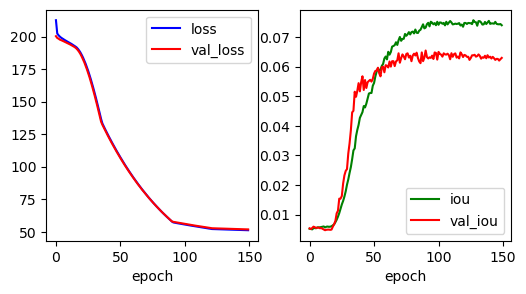

In [21]:
# plot loss and accuracy
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.plot(results.history['loss'], 'b-', label='loss')
plt.plot(results.history['val_loss'], 'r-', label='val_loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(results.history['yolo_metric_fn'], 'g-', label='iou')
plt.plot(results.history['val_yolo_metric_fn'], 'r-', label='val_iou')
plt.xlabel('epoch')
plt.legend()

plt.show()

In [22]:
list(results.history)

['acc',
 'loss',
 'yolo_metric_fn',
 'val_acc',
 'val_loss',
 'val_yolo_metric_fn',
 'learning_rate']

### Evaluate model on test set

In [23]:
YOLO.evaluate(testset)

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - acc: 0.0000e+00 - loss: 51.8217 - yolo_metric_fn: 0.0614


[51.884159088134766, 0.0, 0.062329817563295364]

### Test prediction on a random sample

Actual image is:


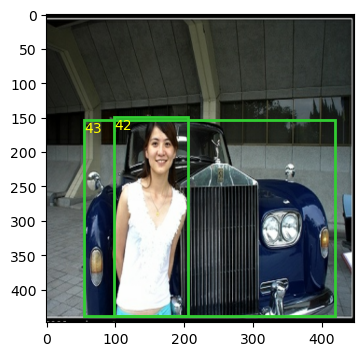

42 : person
43 : car
My prediction is:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


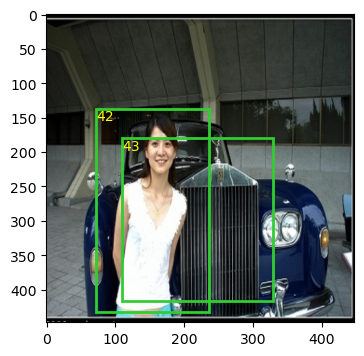

42 : person
43 : car


In [32]:
idx = np.random.randint(n_test-1)

for element in ds_test.skip(idx).take(1):
    image, y_test = tfds_augmtd_4_YOLO(element, preprocess=False)
    X_test = keras.applications.resnet50.preprocess_input(image) # if ResNet50 is used
    image = image/255
    X_test = tf.expand_dims(X_test, axis=0)
    y_test = tf.expand_dims(y_test, axis=0)

print('Actual image is:')

plt.figure(figsize=(4,4))
plt.imshow(image)
axs = plt.gca()   # get current axes
img_h, img_w, _ = image.shape

for i in range(7):
    for j in range(7):
        if y_test[0,i,j,0]==1:
            c_y, c_x, c_h, c_w = y_test[0,i,j,1:5]
            c_y, c_x = (c_y + i)/7, (c_x + j)/7
            obj_y, obj_x, obj_h, obj_w = (c_y-c_h/2)*img_h, (c_x-c_w/2)*img_w, c_h*img_h, c_w*img_w
            bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h, linewidth=2, edgecolor='limegreen', fill = False)
            axs.add_patch(bbox)
            plt.text(obj_x+1, obj_y+17, str(i)+str(j), color='yellow')

plt.show()

for i in range(7):
    for j in range(7):
        if y_test[0,i,j,0]==1:
            print(str(i)+str(j),':',classes[np.argmax(y_test[0,i,j,10:])])

print('My prediction is:')

y_preds = YOLO.predict(X_test)

y_nms_bxs, y_nms_scr, y_nms_cls, y_val_det = yolo_predict_fn(y_preds, threshold=0.2)

plt.figure(figsize=(4,4))
plt.imshow(image)
axs = plt.gca()   # get current axes

for m in range(y_val_det[0]):
    y_1, x_1, y_2, x_2 = y_nms_bxs[0,m]
    c_y, c_x = (y_1+y_2)/2, (x_1+x_2)/2
    i, j = int(c_y*7), int(c_x*7)
    obj_y, obj_x, obj_h, obj_w = y_1*img_h, x_1*img_w, (y_2-y_1)*img_h, (x_2-x_1)*img_w
    bbox = patches.Rectangle((obj_x,obj_y), obj_w, obj_h, linewidth=2, edgecolor='limegreen', fill = False)
    axs.add_patch(bbox)
    plt.text(obj_x+1, obj_y+17, str(i)+str(j), color='yellow')

plt.show()

for m in range(y_val_det[0]):
    y_1, x_1, y_2, x_2 = y_nms_bxs[0,m]
    c_y, c_x = (y_1+y_2)/2, (x_1+x_2)/2
    i, j = int(c_y*7), int(c_x*7)
    print(str(i)+str(j),':',classes[int(y_nms_cls[0,m].numpy())])


(c) 2026 S. W. Lee